## SF Stencils

We follow:
- Seta, Amit, and Christoph Federrath. "Structure functions with higher-order stencils as a probe to separate small-and large-scale magnetic fields." Monthly Notices of the Royal Astronomical Society 533.2 (2024): 1875-1886.
- Cho, Jungyeon. "A technique for removing large-scale variations in regularly and irregularly spaced data." The Astrophysical Journal 874.1 (2019): 75.

and also include the methods to calculate higher-order stencils for SF calculations.

These higher-order stencils help to remove large-scale polynomial behaviour in the total field.

For our example, we generate a fluctuation field, and add a large-scale sinusoidal field.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sys
import os
sys.path.insert(0, os.path.abspath('../../../'))
# Utility to make plots look nice
from kea.utils.plotting import modify_latex_rc, make_ax_step, pretty_axes
# modify_latex_rc()
# modify_latex_rc()

from kea.simulator import make_field

# Set number of grid points
N = 256
# Number of dimensions (two-dimensional)
D = 2
# We have the same number of grid points in each dimension
grid_dims = (N,)*D

# Make the (fluctuation) field
d_field = make_field(grid_dims,
                   spectrum_kwargs={'powerlaw': -8./3., 'cutoff_scale': 5.},
                   spectrum_function='cutoff_powerlaw',
                   seed=1, normalize_output=True)
X, Y = np.indices(grid_dims)
mean_field = 10.*np.sin(X/32.)
total_field = mean_field + d_field

The total field is the sum of the fluctuations and the large-scale sinusoidal motions.

<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_147385/336418505.py:9: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax[1].set_title('$\delta$')
/tmp/ipykernel_147385/336418505.py:10: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is a

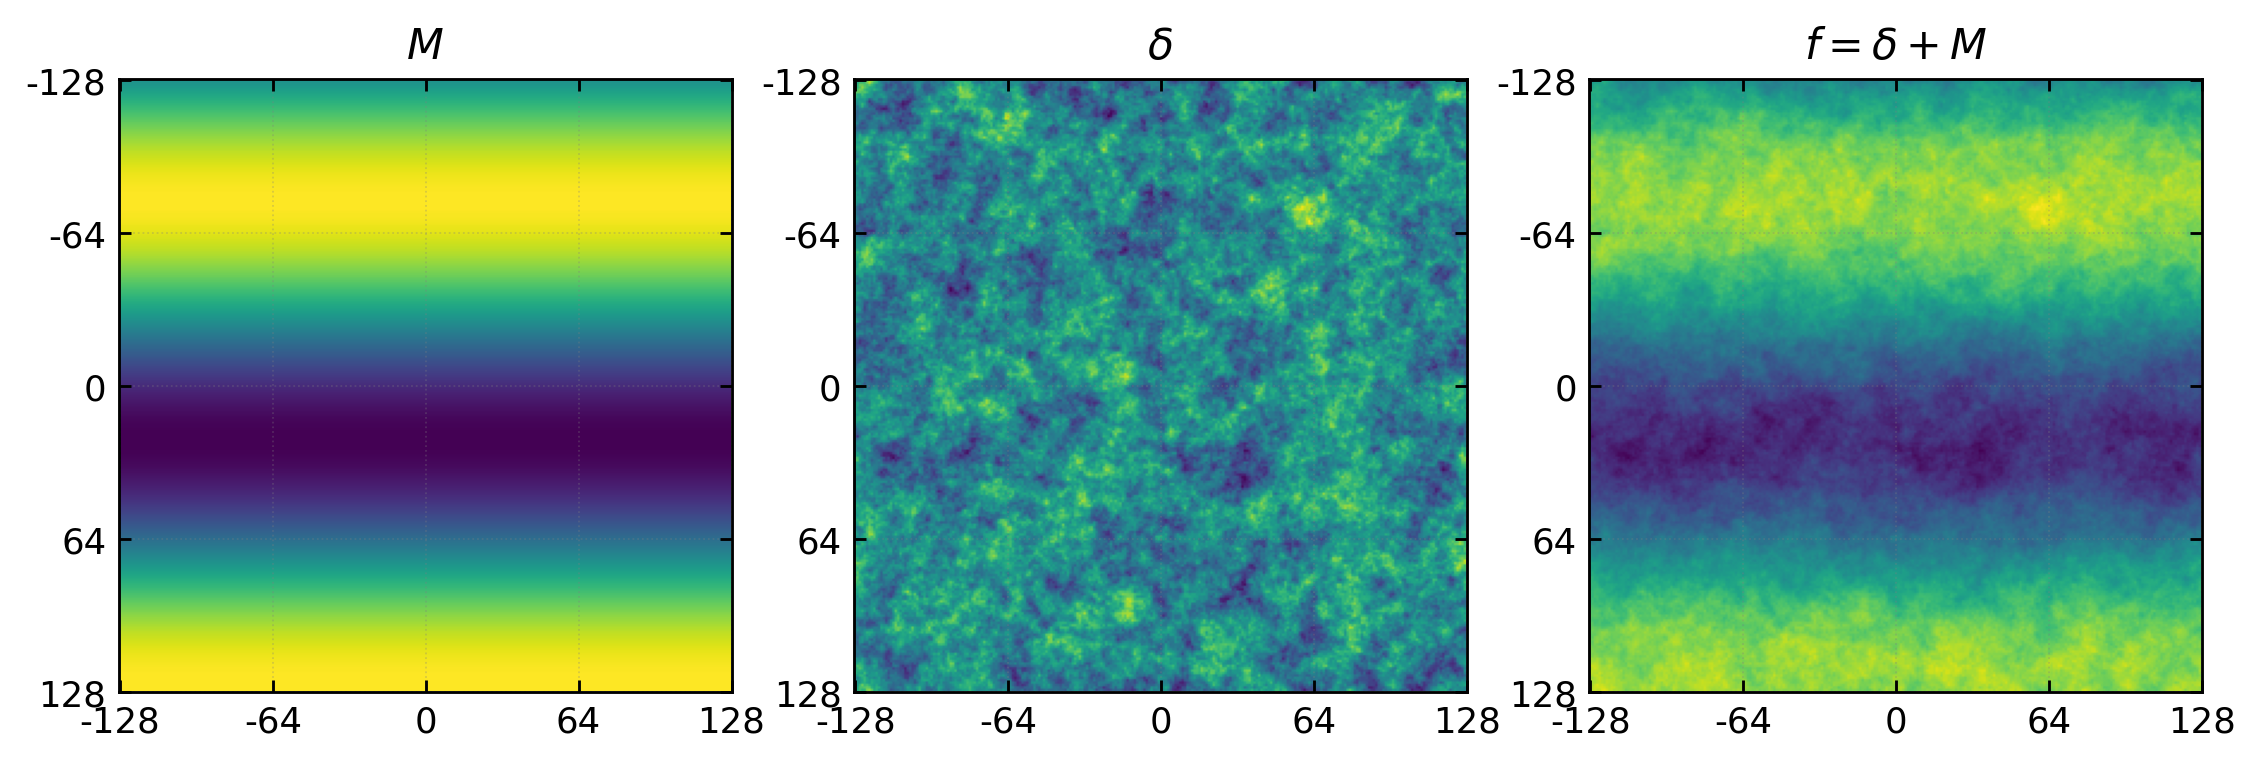

In [21]:
## Plot
fig, ax = plt.subplots(1, 3, figsize=(3.5*3., 3.5), dpi=256)

ax[0].imshow(mean_field)
ax[1].imshow(d_field)
ax[2].imshow(total_field)

ax[0].set_title('$M$')
ax[1].set_title('$\delta$')
ax[2].set_title('$f = \delta + M$')

t,l = make_ax_step(N)
for axx in ax:
    pretty_axes(axx)
    axx.set_xticks(t,l)
    axx.set_yticks(t,l)


Then, we calculate the n-pt SFs using the `n_pt` parameter.

For showcase, we calculate the SFs for the fluctuations only, as well as the total field (fluctuations + mean field).

In [3]:
from kea.statistics.statfunc import structure_function

ell, sf_d = structure_function(d_field, n_pt=2)
ell, sf_d3pt = structure_function(d_field, n_pt=3)

ell, sf2pt = structure_function(total_field, n_pt=2)
ell, sf3pt = structure_function(total_field, n_pt=3)
ell, sf4pt = structure_function(total_field, n_pt=4)
ell, sf5pt = structure_function(total_field, n_pt=5)

<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
/tmp/ipykernel_147385/1139352155.py:12: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  ax[0].set_title('$\delta$-2pt')
/tmp/ipykernel_147385/1139352155.py:13: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw st

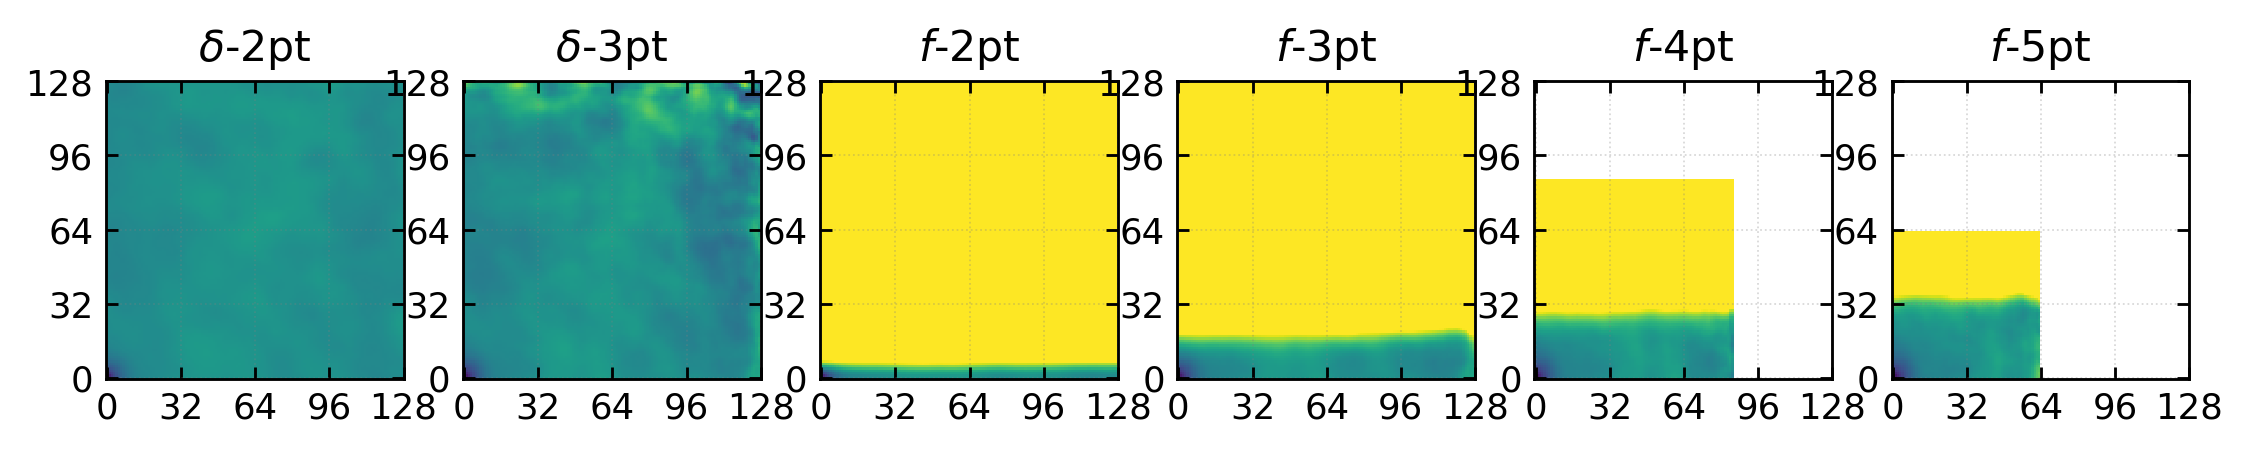

In [23]:
fig, ax = plt.subplots(1, 6, figsize=(1.75*6., 1.75), dpi=256)

cmin, cmax = 0., 4.

ax[0].imshow(sf_d.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)
ax[1].imshow(sf_d3pt.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)
ax[2].imshow(sf2pt.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)
ax[3].imshow(sf3pt.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)
ax[4].imshow(sf4pt.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)
ax[5].imshow(sf5pt.reshape((N//2,N//2)), origin='lower', interpolation='none', vmin=cmin, vmax=cmax)

ax[0].set_title('$\delta$-2pt')
ax[1].set_title('$\delta$-3pt')

ax[2].set_title('$f$-2pt')
ax[3].set_title('$f$-3pt')
ax[4].set_title('$f$-4pt')
ax[5].set_title('$f$-5pt')

t,_ = make_ax_step(N//2)
for axx in ax:
    pretty_axes(axx)
    axx.set_xticks(t)
    axx.set_yticks(t)


The result is shown below. The 2 point SF (blue) that includes the mean components varies significantly in slope, variance, and correlation scale when compared to the 2 point SF of the fluctuations alone (black dashed).

Whereas the 3,4,5 point SFs of the total field better match the 2,3 point SFs of the fluctuations.

In [15]:
from kea.utils import geometry
from kea.utils import binning

def bin_sf(ell, sf):
    dx, dk = geometry.get_dxdk(grid_dims)
    physical_lags = np.linalg.norm(ell, axis=1).reshape((N//2,)*D)*dx[0]
    bins_sf, binned_sf, _ = binning.bin_data(
        physical_lags, sf.reshape((N//2,N//2)), bin_func=np.nanmean, min_bin=dx[0]-dx[0]/2, max_bin=geometry.DEFAULT_PHYS_SCALE/2., cut_excess=True, nan_small=False, ignore_nan=True, bin_loc='center')
    return bins_sf, binned_sf

ell_b2, sf2pt_b = bin_sf(ell, sf2pt)
ell_b3, sf3pt_b = bin_sf(ell, sf3pt)
ell_b4, sf4pt_b = bin_sf(ell, sf4pt)
ell_b5, sf5pt_b = bin_sf(ell, sf5pt)

ell_bd, sf_d_b = bin_sf(ell, sf_d)
ell_bd3, sf_d3pt_b = bin_sf(ell, sf_d3pt)


/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/mark.bishop/miniconda3/envs/kea/lib/python3.14/site-packages/scipy/stats/_binned_sta

(0.1, 400.0)

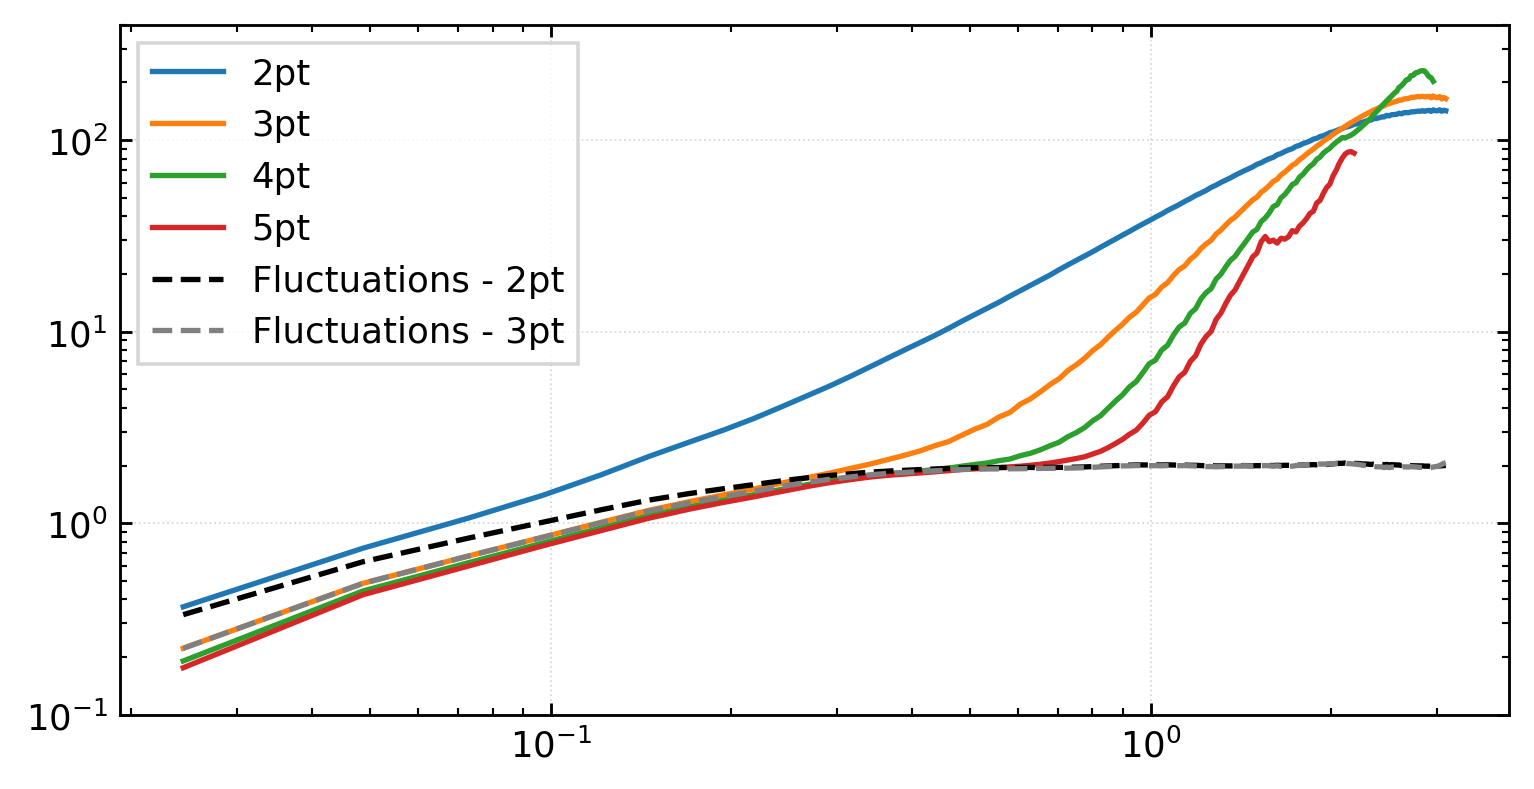

In [24]:
fig, ax = plt.subplots(1, 1, figsize=(7., 3.5), dpi=256)

ax.plot(ell_b2, sf2pt_b, linestyle='-', label='2pt')
ax.plot(ell_b3, sf3pt_b, linestyle='-', label='3pt')
ax.plot(ell_b4, sf4pt_b, linestyle='-', label='4pt')
ax.plot(ell_b5, sf5pt_b, linestyle='-', label='5pt')

ax.plot(ell_bd, sf_d_b, linestyle='--', color='black', label='Fluctuations - 2pt')
ax.plot(ell_bd3, sf_d3pt_b, linestyle='--', color='gray', label='Fluctuations - 3pt')

ax.legend(fancybox=False)

ax.set_yscale('log')
ax.set_xscale('log')
pretty_axes(ax)
ax.set_ylim((1e-1, 4e2))
